#  **Практическое занятие №8. Text2image модели. Основные архитектуры**

In [18]:
import numpy as np

In [19]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Inception Score

Документация по Inception Score на torch https://pytorch.org/ignite/generated/ignite.metrics.InceptionScore.html

### Применяем Inception v3 к конкретному изображению

In [20]:
import torch
import torchvision
print(torchvision.__version__)

0.26.0+cpu


In [21]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'inception_v3', pretrained=True)
model.eval()

Using cache found in /home/dlanb/.cache/torch/hub/pytorch_vision_v0.10.0
/home/dlanb/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dlanb/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [23]:
!/bin/python3.12 -m pip install requests

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [requests]


In [24]:
from PIL import Image
from torchvision import transforms, datasets
import torchshow as ts

import io
import requests
import PIL

In [25]:
def download_image(url):
    resp = requests.get(url)
    resp.raise_for_status()
    return PIL.Image.open(io.BytesIO(resp.content))

In [26]:
def preprocess(input_image):
    transform = transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = transform(input_image)
    #print(input_tensor.shape)
    input_batch = input_tensor.unsqueeze(0)
    #print(input_batch.shape)
    return input_batch

In [27]:
image = download_image('https://assets.bwbx.io/images/users/iqjWHBFdfxIU/iKIWgaiJUtss/v2/1000x-1.jpg')

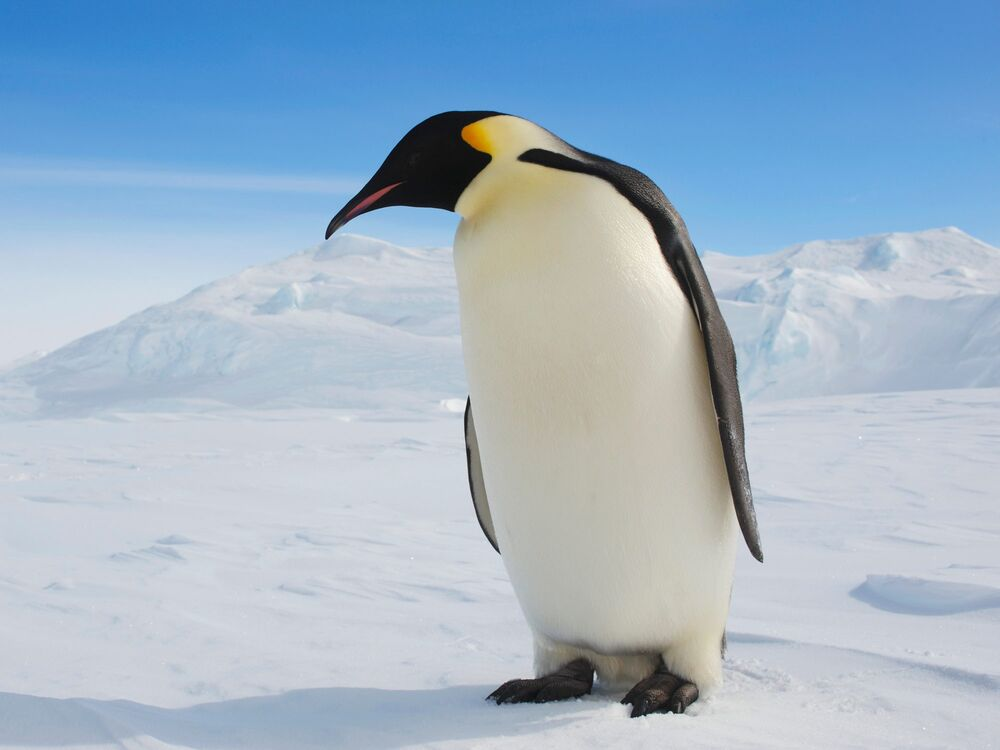

In [28]:
image

In [29]:
input_batch = preprocess(image)

In [30]:
input_batch.shape

torch.Size([1, 3, 299, 299])

In [31]:
with torch.no_grad():
    output = model(input_batch)

In [32]:
output.shape

torch.Size([1, 1000])

In [33]:
probabilities = torch.nn.functional.softmax(output[0], dim=0)

In [34]:
sum(probabilities)

tensor(1.0000)

<function matplotlib.pyplot.show(close=None, block=None)>

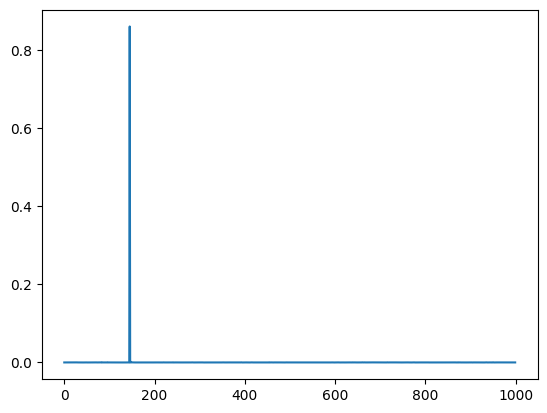

In [35]:
import matplotlib.pyplot as plt

plt.plot(np.arange(1000), probabilities)
plt.show

In [36]:
np.argmax(probabilities)

tensor(145)

In [18]:
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://raw.githubusercontent.]87Saving 'imagenet_classes.txt'
87imagenet_classes.txt 100% [=============================>]    5.10K    --.-KB/s87HTTP response 200  [https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt]
87imagenet_classes.txt 100% [=============================>]    5.10K    --.-KB/s87[Files: 1  Bytes: 5.10K [15.80K]8

In [37]:
with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]

top5_prob, top5_catid = torch.topk(probabilities, 5)
for i in range(top5_prob.size(0)):
    print(categories[top5_catid[i]], top5_prob[i].item())

king penguin 0.8609986901283264
killer whale 0.0015104621415957808
prairie chicken 0.0007645606528967619
European fire salamander 0.0005564501625485718
toucan 0.0005367799894884229


### Посчитаем Inception Score на данных из CIFAR-10 (как будто эти картинки выдал генератор)

In [38]:
cifar_transform = transforms.Compose([
        transforms.Resize(299),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

In [39]:
from PIL import Image
from torchvision import transforms, datasets
import torchshow as ts
import torchvision

import io
import requests
import PIL

In [40]:
cifar10_testset = torchvision.datasets.CIFAR10(root='cifar', train=False, download=True, transform=cifar_transform)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100.0%
/home/dlanb/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


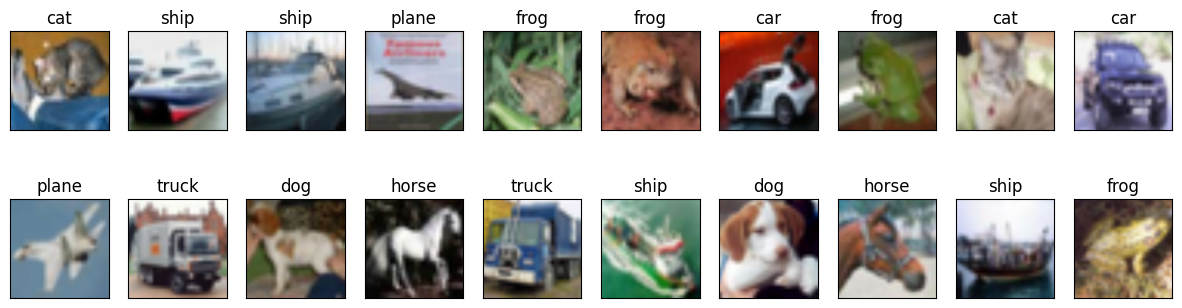

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(cifar10_testset[i][0].permute(1, 2, 0)
              )
    plt.xticks([])
    plt.yticks([])
    plt.title(classes[cifar10_testset[i][1]])

plt.show()

In [45]:
!/bin/python3.12 -m pip install pytorch-ignite --user

In [46]:
from collections import OrderedDict

import torch
from torch import nn, optim

from ignite.engine import *
from ignite.handlers import *
from ignite.metrics import *
from ignite.utils import *
from ignite.contrib.metrics.regression import *
from ignite.contrib.metrics import *

from torch.utils.data import DataLoader

In [28]:
!pip install pytorch-ignite

Defaulting to user installation because normal site-packages is not writeable


In [47]:
from ignite.engine import Engine
from ignite.metrics import InceptionScore

In [48]:
inceptor = nn.Sequential(
    model,
    nn.Softmax(1)
)

In [49]:
def process_function(engine, batch):
    # ...
    return batch

engine = Engine(process_function)
metric = InceptionScore(num_features=1000, feature_extractor=inceptor)
metric.attach(engine, "is")

dataloader = DataLoader(cifar10_testset, batch_size=100, shuffle=True)
data, labels = next(iter(dataloader))

# ...
state = engine.run([data], 1)
print(f"InceptionScore: {state.metrics['is']}")

INFO:ignite.engine.engine.Engine:Engine run starting with max_epochs=1.
INFO:ignite.engine.engine.Engine:Epoch[1] Complete. Time taken: 00:00:04.461
INFO:ignite.engine.engine.Engine:Engine run finished. Time taken: 00:00:04.462


InceptionScore: 2.6605478798720443


### Автоэнкодер

In [50]:
import numpy as np
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader,random_split
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import torchshow as ts
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset, DataLoader, random_split

In [51]:
mnist_train_val = datasets.MNIST(root='mnist', train=True, download=True, transform=transforms.ToTensor())
mnist_train, mnist_val = random_split(mnist_train_val, [0.8, 0.2])

100.0%
100.0%
100.0%
100.0%


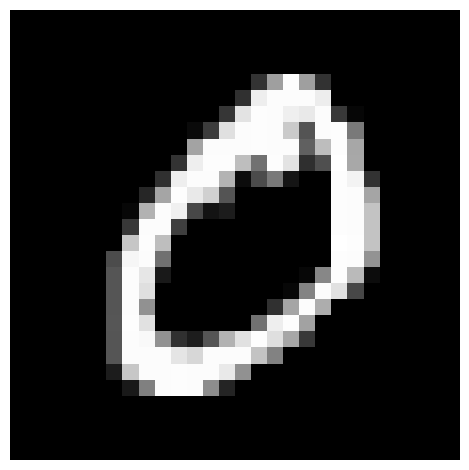

In [52]:
# example
img, cls = mnist_train_val[1]
ts.show(img)

In [53]:
img.shape

torch.Size([1, 28, 28])

In [54]:
class SimpleAutoEncoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim=1024, img_shape=(1, 28, 28)):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(np.prod(img_shape), hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Linear(hidden_dim, np.prod(img_shape)),
            nn.Sigmoid(),
            nn.Unflatten(1, img_shape)
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encoder(x)
        y = self.decoder(z)
        return y

    def process(self, x):
        return self(x)

Напишем вспомогальные функции

In [56]:
!/bin/python3.12 -m pip install tqdm --user

In [57]:
from tqdm import tqdm

# одна эпоха обучения
def run_epoch(ae, opt, loss, dataloader, is_train=True):
    ae.train(is_train)
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for x, _ in tqdm(dataloader):
            x = x.to(device)
            l = loss(x, ae(x))
            if (is_train):
                opt.zero_grad()
                l.backward()
                opt.step()
            total_loss += l.item()
    return total_loss / len(dataloader.dataset)

In [58]:
# отрисовка лосса
def plot_loss(loss, title, num_epochs):
    plt.title(title)
    plt.plot(loss)
    plt.grid()
    plt.xticks(np.arange(num_epochs))

def plot_losses(train, val, num_epochs):
    plt.figure(figsize=(16, 4))
    plt.subplot(1, 2, 1)
    plot_loss(train, f'Train Loss = {train[-1]}', num_epochs)
    plt.subplot(1, 2, 2)
    plot_loss(val, f'Val Loss = {val[-1]}', num_epochs)
    plt.show()

In [59]:
# отрисовка изображений - реальных и после автоэнкодера
def show_examples(ae, dataset, size):
    ae.eval()
    with torch.no_grad():
        idxs = np.random.randint(0, len(dataset), size)
        x = torch.stack([dataset[i][0] for i in idxs]).to(device)
        y = ae.process(x)
        print("Original images")
        ts.show(x, nrows=1, figsize=(12, 2))
        print("Reconstructed")
        ts.show(y, nrows=1, figsize=(12, 2))

In [75]:
from IPython.display import clear_output

def run_train_loop(ae, opt, loss, train_loader, val_loader, num_epochs, ex_size):
    train_hist = []
    val_hist = []
    for e in range(num_epochs):
        print("Trainin...")
        train_loss = run_epoch(ae, opt, loss, train_loader)
        train_hist.append(train_loss)
        print("Validating...")
        val_loss = run_epoch(ae, opt, loss, val_loader, is_train=False)
        val_hist.append(val_loss)
        clear_output()
        plot_losses(train_hist, val_hist, num_epochs)
        show_examples(ae, val_loader.dataset, ex_size)

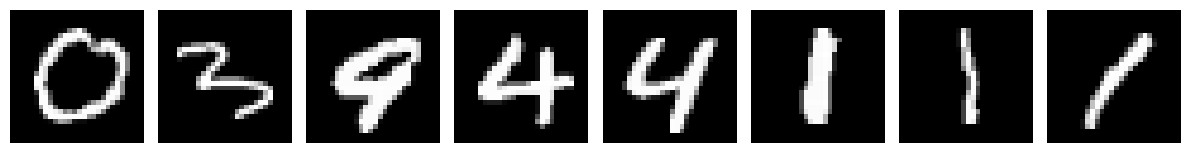

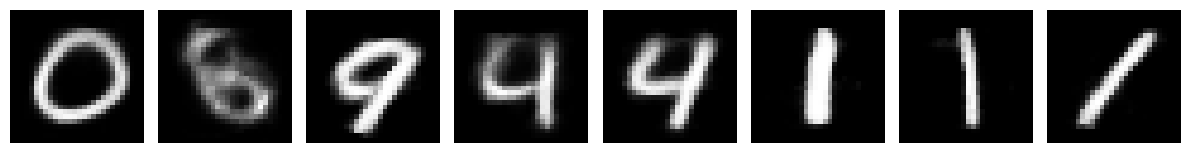

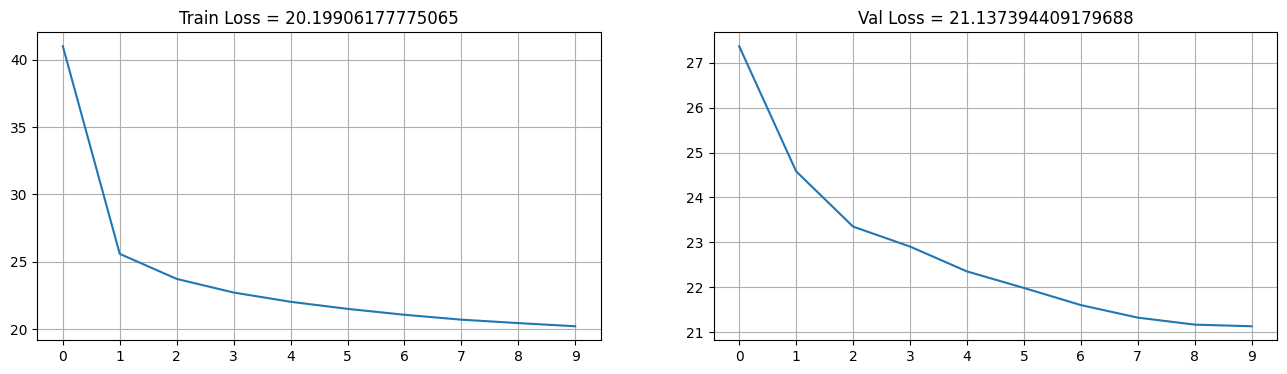

Original images
Reconstructed


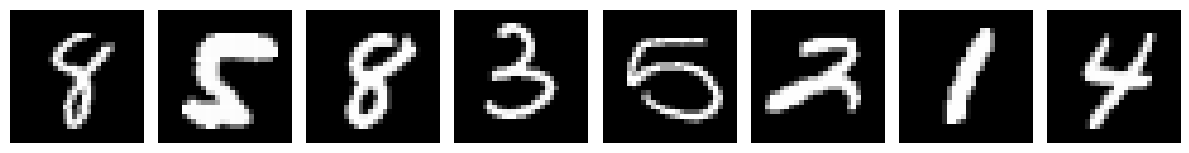

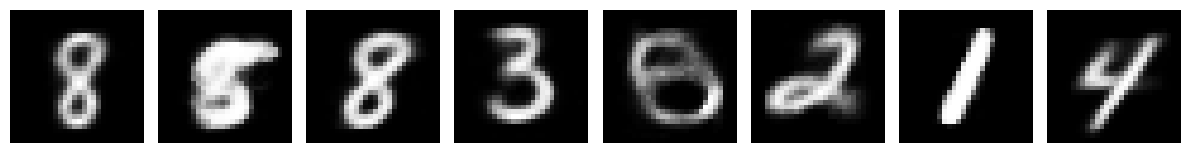

In [61]:
batch_size = 256
num_epochs = 10
lat_dim = 4 # размерность скрытого пространства
ex_size = 8 # число примеров для отрисовки

train_loader = DataLoader(mnist_train, batch_size)
val_loader = DataLoader(mnist_val, batch_size)

sae = SimpleAutoEncoder(lat_dim).to(device)
sae_opt = optim.Adam(sae.parameters())
sae_loss = nn.MSELoss(reduction='sum')

run_train_loop(sae, sae_opt, sae_loss,
               train_loader, val_loader, num_epochs, ex_size)

In [62]:
data, labels = next(iter(val_loader))

In [63]:
img = data[0]
sae.encode(img)

tensor([[-1.7666, -1.9142, -0.4602,  3.2713]], grad_fn=<AddmmBackward0>)

Посмотрим, как выглядит скрытое пространство автоэнкодера:

In [64]:
def show_enc_dist(ae, xi, yi, dataset, size):
    idxs = np.random.randint(0, len(dataset), size)
    ae.eval()
    with torch.no_grad():
        z = ae.encode(torch.stack([dataset[i][0] for i in idxs]).to(device))
    x = z[:,xi].cpu().numpy()
    y = z[:,yi].cpu().numpy()
    plt.figure(figsize=(8, 8))
    plt.scatter(x, y, c = [dataset[i][1] for i in idxs])
    plt.show()

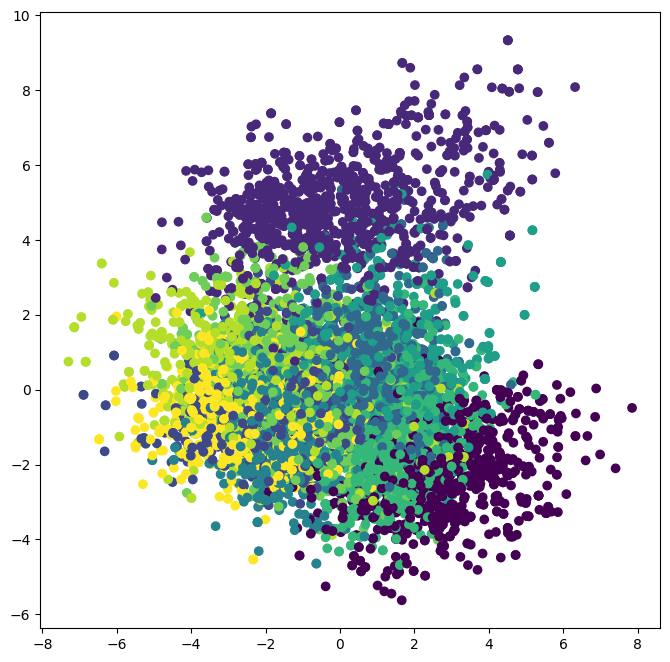

In [65]:
show_enc_dist(sae, 0, 1, mnist_val, 10000)

In [66]:
class SimpleVariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dim, img_shape=(1, 28, 28)):
        super().__init__()

        self.encoder_common = nn.Sequential(
            nn.Flatten(),
            nn.Linear(np.prod(img_shape), 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU()
        )
        self.encoder_m = nn.Linear(512, latent_dim)
        self.encoder_s = nn.Linear(512, latent_dim)

        self.N = torch.distributions.Normal(0, 1)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 512),
            nn.LeakyReLU(),
            nn.Linear(512, np.prod(img_shape)),
            nn.Sigmoid(),
            nn.Unflatten(1, img_shape)
        )

    def encode(self, x):
        x = self.encoder_common(x)
        m = self.encoder_m(x)
        s = torch.exp(self.encoder_s(x))
        return m + s * self.N.sample(m.shape)

    def forward(self, x):
        x = self.encoder_common(x)
        m = self.encoder_m(x)
        s = torch.exp(self.encoder_s(x))
        z = m + s * self.N.sample(m.shape)
        y = self.decoder(z)
        return y, m, s

    def process(self, x):
        return self(x)[0]

In [68]:
from tqdm import tqdm

# одна эпоха обучения
def run_epoch(ae, opt, loss, dataloader, is_train=True):
    ae.train(is_train)
    total_loss = 0.0
    with torch.set_grad_enabled(is_train):
        for x, _ in tqdm(dataloader):
            x = x.to(device)
            reconstruction, mu, sigma = ae(x)
            recon_loss = loss(reconstruction, x)
            kl_loss = -0.5 * torch.sum(1 + torch.log(sigma**2) - mu**2 - sigma**2)
            l = recon_loss + kl_loss
            if (is_train):
                opt.zero_grad()
                l.backward()
                opt.step()
            total_loss += l.item()
    return total_loss / len(dataloader.dataset)

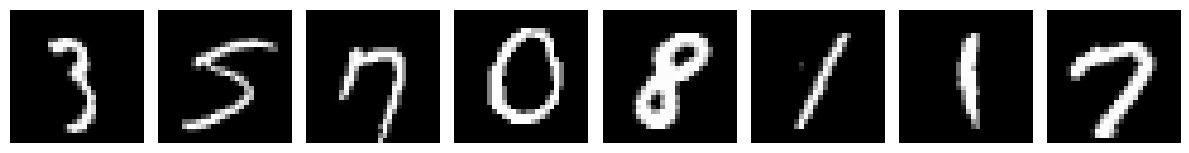

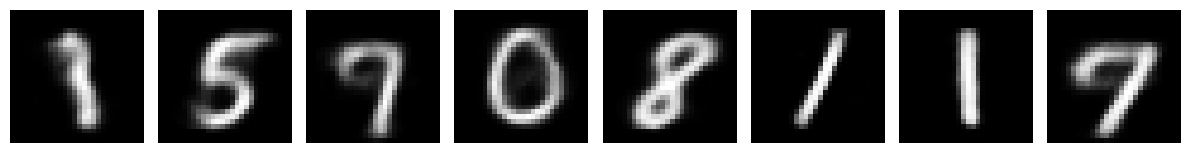

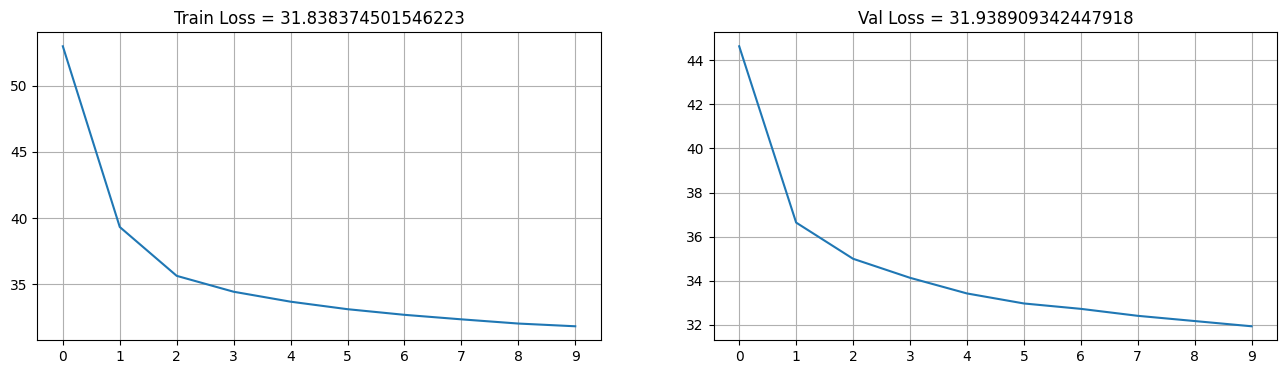

Original images
Reconstructed


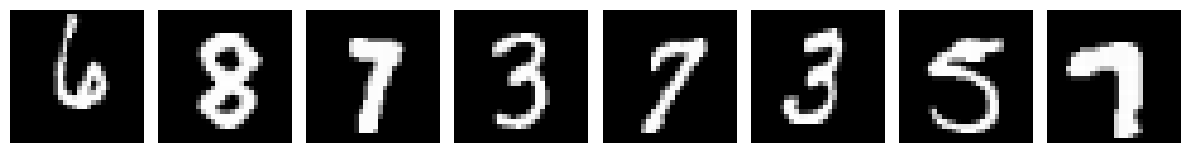

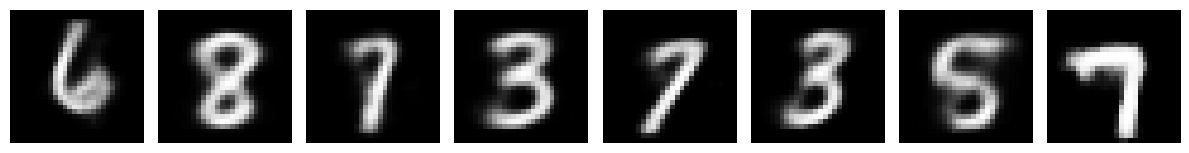

In [69]:
batch_size = 256
num_epochs = 10
lat_dim = 4 # размерность скрытого пространства
ex_size = 8 # число примеров для отрисовки

train_loader = DataLoader(mnist_train, batch_size)
val_loader = DataLoader(mnist_val, batch_size)

sae = SimpleVariationalAutoEncoder(lat_dim).to(device)
sae_opt = optim.Adam(sae.parameters())
sae_loss = nn.MSELoss(reduction='sum')

run_train_loop(sae, sae_opt, sae_loss,
               train_loader, val_loader, num_epochs, ex_size)

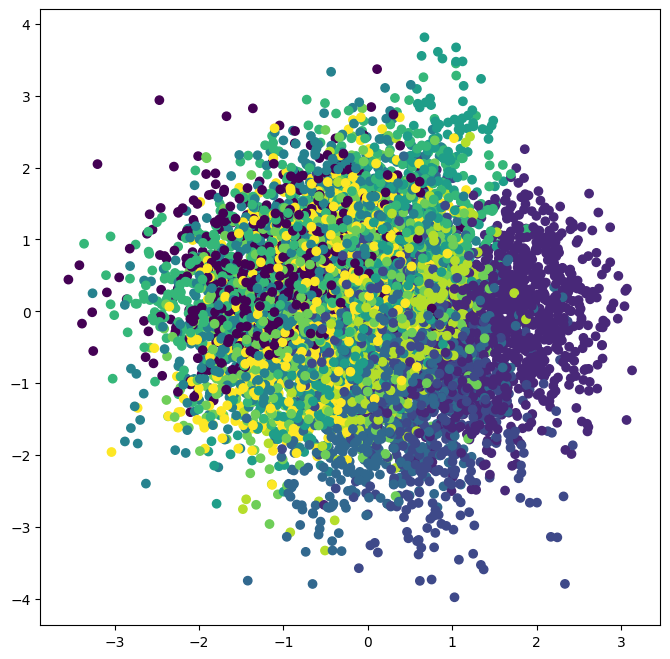

In [ ]:
show_enc_dist(sae, 0, 1, mnist_val, 10000)

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import Variable

def get_latent_vectors(model, images, device):
    """Пропускает изображения через энкодер, чтобы получить векторы z"""
    model.eval()
    with torch.no_grad():
        # images_pair приходят как (2, 1, 28, 28)
        images = images.to(device)
        
        # Пропускаем через общую часть энкодера
        hidden = model.encoder_common(images)
        
        # Получаем mu (среднее значение распределения)
        # Мы используем mu, а не случайный сэмпл z, 
        # чтобы интерполяция была максимально стабильной
        mu = model.encoder_m(hidden)
        
        return mu.cpu().numpy()

def generate_morphing(model, images_pair, lat_dim, num_steps=10, device='cuda'):
    """Генерирует последовательность кадров плавного перехода"""
    model.eval()
    
    # 1. Получаем латентные векторы для старта и финиша (берём среднее - m)
    z_vectors = get_latent_vectors(model, images_pair, device)
    z_start = z_vectors[0]
    z_end = z_vectors[1]
    
    # 2. Создаем массив векторов-интерполяций z_t
    # t_steps - это веса от 0 до 1
    t_steps = np.linspace(0, 1, num_steps)
    z_morph = np.zeros((num_steps, lat_dim))
    
    for i, t in enumerate(t_steps):
        # Формула линейной интерполяции: z_t = (1-t)*z_start + t*z_end
        z_morph[i] = (1 - t) * z_start + t * z_end
        
    # 3. Превращаем z back в изображения через декодер
    z_morph_torch = torch.from_numpy(z_morph).float().to(device)
    with torch.no_grad():
        generated_imgs = model.decoder(z_morph_torch)
        generated_imgs = generated_imgs.cpu().numpy()
        
    return generated_imgs

def plot_morphing(generated_imgs, title="Morphing Progression"):
    """Рисует сетку из сгенерированных кадров"""
    num_steps = generated_imgs.shape[0]
    plt.figure(figsize=(num_steps, 2))
    plt.suptitle(title, fontsize=16)
    
    for i in range(num_steps):
        ax = plt.subplot(1, num_steps, i + 1)
        # generated_imgs имеет форму (N, 1, 28, 28)
        plt.imshow(generated_imgs[i, 0], cmap='gray')
        plt.axis('off')
        # Подписываем шаг t
        ax.set_title(f"t={i/(num_steps-1):.2f}", fontsize=8)
    plt.show()

# Вспомогательная функция для получения картинок конкретных классов
def get_images_of_classes(dataset, class_a, class_b):
    """Находит по одному примеру каждой цифры в датасете"""
    img_a, img_b = None, None
    for img, label in dataset:
        if label == class_a and img_a is None:
            img_a = img
        if label == class_b and img_b is None:
            img_b = img
        if img_a is not None and img_b is not None:
            break
    # Объединяем в батч (2, 1, 28, 28)
    return torch.stack([img_a, img_b])

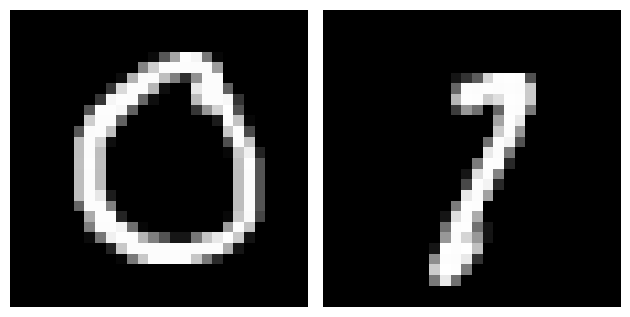

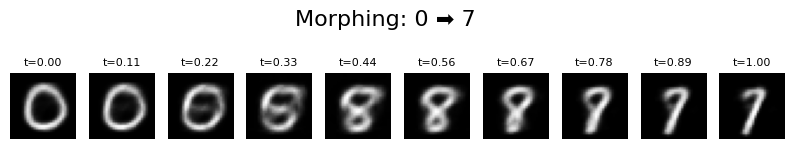

In [74]:
# 1. Выбираем пару классов для интерполяции (0 и 7)
classes_to_morph = (0, 7)
images_pair = get_images_of_classes(mnist_val, classes_to_morph[0], classes_to_morph[1])

# Покажем исходные картинки
ts.show(images_pair, title=f"Source images: {classes_to_morph[0]} and {classes_to_morph[1]}")

# 2. Генерируем 10 кадров перехода
# lat_dim должен соответствовать тому, с которым вы обучали VAE (4 в коде)
generated_morph = generate_morphing(sae, images_pair, lat_dim=4, num_steps=10, device=device)

# 3. Отрисовываем прогресс
plot_morphing(generated_morph, title=f"Morphing: {classes_to_morph[0]} ➡️ {classes_to_morph[1]}")